# IPL Venue Analysis — Batting First vs Batting Second
### Which stadiums favour the chasing team across eras?
ISSUE: #E4

---
## 0. Imports

In [2]:
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt   
import seaborn as sns     


sns.set_theme(style='whitegrid')
plt.rcParams['axes.titlesize'] = 13

print('Libraries loaded ')

Libraries loaded 


---
## 1. Load the Data

In [5]:
df = pd.read_csv('../data/matches.csv')

print(f'Total rows   : {len(df)}')
print(f'Columns      : {list(df.columns)}')
print(f'Seasons      : {sorted(df.season.unique())}')

df.head()

Total rows   : 1095
Columns      : ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
Seasons      : ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


---
## 2. Clean the Data

In [7]:
# Cleaning up the results - I only care about clear wins (runs/wickets)
# This filters out the ties/no-results that would mess up the win ratio
df = df[df['result'].isin(['runs', 'wickets'])].copy()

# Cleaning the Venue names
# I noticed Wankhede had two names while checking the value_counts()
df['venue'] = df['venue'].replace('Wankhede Stadium, Mumbai', 'Wankhede Stadium')

# Converting 'season' to a year number
# Some seasons are '2008' and some are '2009/10', so I'm splitting them
df['year'] = df['season'].apply(lambda x: int(str(x).split('/')[-1]))

# Splitting into Eras for the Issue #E4 requirement
# Using 2015 as the cutoff point
df['era'] = 'Modern IPL (2015+)'
df.loc[df['year'] < 2015, 'era'] = 'Early IPL (pre-2015)'

# Just a quick check to see if the split worked
print("Matches per Era:")
print(df['era'].value_counts())# Keep only matches won by runs or wickets — no ties, no no-results
df = df[df['result'].isin(['runs', 'wickets'])].copy()
print(f'After removing ties/no-results: {len(df)} matches')

# Fix Wankhede: it appears under two slightly different names in the CSV
# We merge both into one consistent name
df['venue'] = df['venue'].str.replace(
    'Wankhede Stadium, Mumbai', 'Wankhede Stadium', regex=False
)

# Parse the season into a plain year number
# e.g. '2007/08' → 2008,  '2009' → 2009
def parse_season(s):
    parts = str(s).split('/')
    return int(parts[-1])   # take the last part after the slash

df['year'] = df['season'].apply(parse_season)

# Assign each match to an era
df['era'] = df['year'].apply(
    lambda y: 'Early IPL (pre-2015)' if y < 2015 else 'Modern IPL (2015+)'
)

print(df['era'].value_counts().to_string())

Matches per Era:
era
Modern IPL (2015+)      568
Early IPL (pre-2015)    508
Name: count, dtype: int64
After removing ties/no-results: 1076 matches
era
Modern IPL (2015+)      568
Early IPL (pre-2015)    508


---
## 3. Work Out Who Batted First

In [8]:
# Figuring out who batted first based on the toss
# If they won the toss and chose bat, they are bat_first. 
# Otherwise, the other team is.
df['bat_first'] = df['toss_winner']
df.loc[df['toss_decision'] == 'field', 'bat_first'] = df['team1']
# If the toss winner chose to field and they were team1, then team2 actually batted first
df.loc[(df['toss_decision'] == 'field') & (df['toss_winner'] == df['team1']), 'bat_first'] = df['team2']

# Creating a simple True/False column for if the team batting first won
# (This is easier for me to count later)
df['defending_won'] = df['bat_first'] == df['winner']

# Let's see the win percentages to make sure this makes sense
def_wins = df['defending_won'].sum()
total = len(df)
chase_wins = total - def_wins

print(f"Defending Wins: {def_wins} ({round(def_wins/total*100, 2)}%)")
print(f"Chasing Wins: {chase_wins} ({round(chase_wins/total*100, 2)}%)")

Defending Wins: 492 (45.72%)
Chasing Wins: 584 (54.28%)


---
## 4. Find the Top 10 Venues

In [9]:
# First, I need to see which stadiums have the most matches
# Otherwise, the win ratios won't be statistically significant
top_10_venues = df['venue'].value_counts().head(10)

print("My Top 10 Venues:")
print(top_10_venues)

# Creating a list of these names to filter my main dataframe
top10_list = top_10_venues.index.tolist()

# Filtering... I'm using .copy() to avoid that 'SettingWithCopy' warning later
df_top = df[df['venue'].isin(top10_list)].copy()

print(f"\nFiltered dataframe size: {df_top.shape}")

My Top 10 Venues:
venue
Wankhede Stadium                              117
Eden Gardens                                   77
M Chinnaswamy Stadium                          62
Feroz Shah Kotla                               59
Rajiv Gandhi International Stadium, Uppal      48
Sawai Mansingh Stadium                         47
MA Chidambaram Stadium, Chepauk                47
Dubai International Cricket Stadium            43
Punjab Cricket Association Stadium, Mohali     35
Sharjah Cricket Stadium                        28
Name: count, dtype: int64

Filtered dataframe size: (563, 24)


---
## 5. Core Logic — Chasing Win % per Venue per Era

**Formula:** Chasing Win % = (chasing wins ÷ total matches) × 100  
A value **above 50%** means the chasing team has the advantage at that venue.

In [10]:
# Now for the main part: calculating win rates per venue and era
# I'm using groupby to get the counts for defending wins vs total matches
analysis = df_top.groupby(['venue', 'era'])['defending_won'].agg(['count', 'sum']).reset_index()

# Renaming columns so they actually make sense to me
analysis.columns = ['venue', 'era', 'total_matches', 'defending_wins']

# Calculating the chaser's stats
analysis['chasing_wins'] = analysis['total_matches'] - analysis['defending_wins']
analysis['chasing_win_pct'] = (analysis['chasing_wins'] / analysis['total_matches'] * 100).round(1)

# Some stadium names are way too long for a plot (like 'M.Chinnaswamy Stadium, Bengaluru')
# I'll trim them down to just the first part so the X-axis is readable
analysis['venue_clean'] = analysis['venue'].str.split(',').str[0]

# Checking the numbers before I plot them
print("Chasing Advantage Analysis:")
print(analysis[['venue_clean', 'era', 'chasing_win_pct']].sort_values(by='chasing_win_pct', ascending=False))

Chasing Advantage Analysis:
                            venue_clean                   era  chasing_win_pct
17              Sharjah Cricket Stadium    Modern IPL (2015+)             70.0
14               Sawai Mansingh Stadium  Early IPL (pre-2015)             69.7
1   Dubai International Cricket Stadium    Modern IPL (2015+)             69.2
12   Rajiv Gandhi International Stadium  Early IPL (pre-2015)             65.5
15               Sawai Mansingh Stadium    Modern IPL (2015+)             64.3
2                          Eden Gardens  Early IPL (pre-2015)             62.5
10   Punjab Cricket Association Stadium  Early IPL (pre-2015)             61.3
16              Sharjah Cricket Stadium  Early IPL (pre-2015)             61.1
3                          Eden Gardens    Modern IPL (2015+)             59.5
6                 M Chinnaswamy Stadium  Early IPL (pre-2015)             58.5
19                     Wankhede Stadium    Modern IPL (2015+)             57.5
7                 M Chin

---
## 6. Era Comparison Table — Did the Advantage Flip?

In [11]:
# Now I want to see if the advantage actually flipped between eras
# I'll create a pivot table to compare Early vs Modern side-by-side
era_comp = analysis.pivot(index='venue_clean', columns='era', values='chasing_win_pct')

# Calculating the difference to see how much more (or less) teams like chasing now
era_comp['Shift'] = (era_comp['Modern IPL (2015+)'] - era_comp['Early IPL (pre-2015)']).round(1)

# Logic to see if the stadium "personality" changed
# If it went from <50 to >50 (or vice versa), the advantage flipped
def has_it_flipped(row):
    early = row['Early IPL (pre-2015)']
    modern = row['Modern IPL (2015+)']
    
    # Just checking for stadiums that have data for both eras
    if pd.isna(early) or pd.isna(modern):
        return "Missing Data"
    
    if (early < 50 and modern > 50) or (early > 50 and modern < 50):
        return "YES - Flipped"
    return "No Change"

era_comp['Flip Status'] = era_comp.apply(has_it_flipped, axis=1)

# Sorting it to see the most chasing-friendly grounds at the top
era_comp = era_comp.sort_values('Modern IPL (2015+)', ascending=False)

print("How Stadiums Changed Over Time:")
print(era_comp)

How Stadiums Changed Over Time:
era                                  Early IPL (pre-2015)  Modern IPL (2015+)  \
venue_clean                                                                     
Sharjah Cricket Stadium                              61.1                70.0   
Dubai International Cricket Stadium                  43.3                69.2   
Sawai Mansingh Stadium                               69.7                64.3   
Eden Gardens                                         62.5                59.5   
Wankhede Stadium                                     48.6                57.5   
M Chinnaswamy Stadium                                58.5                57.1   
Feroz Shah Kotla                                     55.0                52.6   
Rajiv Gandhi International Stadium                   65.5                52.6   
Punjab Cricket Association Stadium                   61.3                25.0   
MA Chidambaram Stadium                               40.0                14.3

---
## 7. Visualisation 1 — Grouped Bar Chart

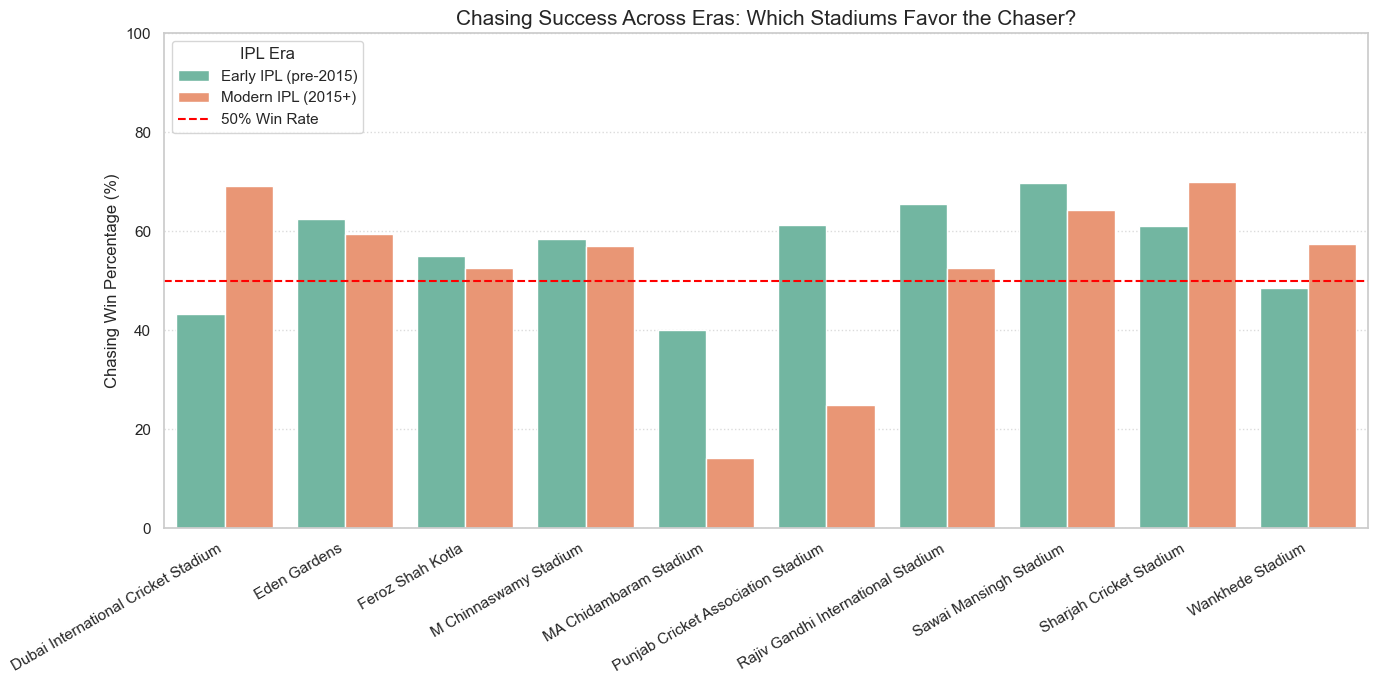

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# First, let's melt the data to make it easier for Seaborn to plot eras side-by-side
plot_data = analysis.rename(columns={'venue_clean': 'Venue', 'era': 'Era', 'chasing_win_pct': 'Chasing_Win_Rate'})

plt.figure(figsize=(14, 7))

# Using a standard seaborn barplot - it's much cleaner than calculating bar offsets manually
sns.barplot(data=plot_data, x='Venue', y='Chasing_Win_Rate', hue='Era', palette='Set2')

# Adding a line at 50% to show the "advantage" threshold
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% Win Rate')

# Formatting the labels so they don't overlap
plt.xticks(rotation=30, ha='right')
plt.title('Chasing Success Across Eras: Which Stadiums Favor the Chaser?', fontsize=15)
plt.ylabel('Chasing Win Percentage (%)')
plt.xlabel('') # Clearer without the "Venue" label
plt.ylim(0, 100)
plt.legend(title='IPL Era', loc='upper left')

plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

---
## 8. Visualisation 2 — Heatmap

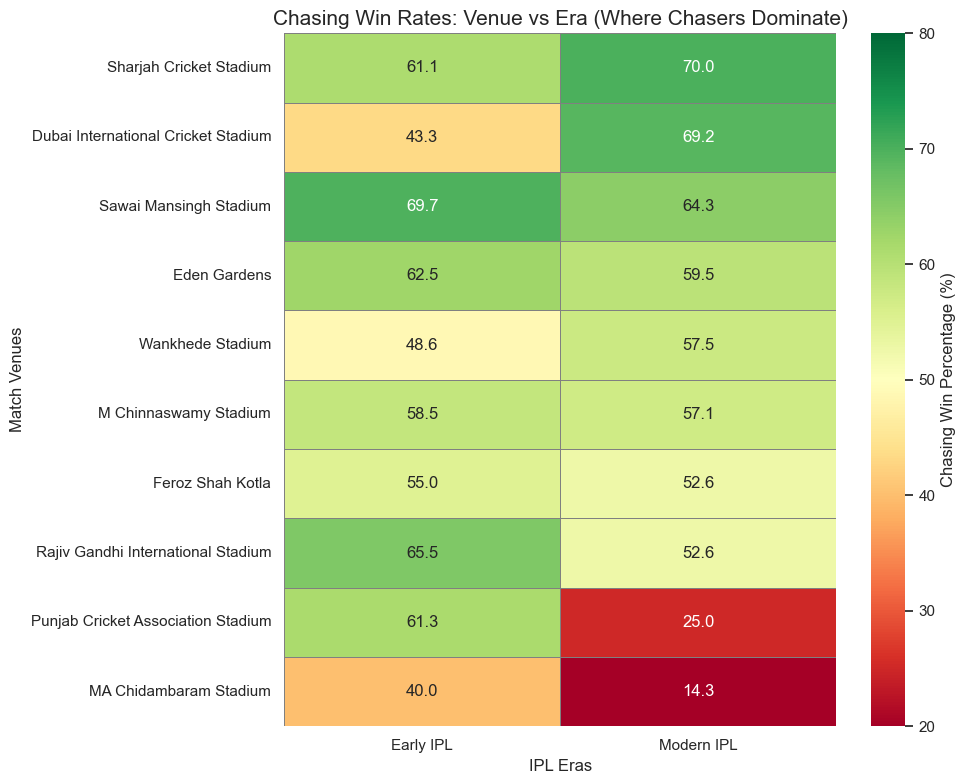

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Since we already have the pivot table (era_comp), 
# let's just use it directly for the heatmap.
heat_data = era_comp[['Early IPL (pre-2015)', 'Modern IPL (2015+)']]

# Renaming columns slightly for cleaner axis labels, but keeping it simple
heat_data.columns = ['Early IPL', 'Modern IPL']

plt.figure(figsize=(10, 8))

# Using a standard seaborn heatmap
# It's cleaner than manually defining everything from scratch
sns.heatmap(
    heat_data,
    annot=True,               # Showing the numbers is crucial for readability
    fmt='.1f',                # 1 decimal place is fine for percentages
    cmap='RdYlGn',            # Sticking with the red-yellow-green to match the insight
    center=50,                # 50% is the neutral point (yellow)
    vmin=20, vmax=80,        # Setting reasonable min/max for the color scale
    linewidths=0.5,           # Small lines for cell separation
    linecolor='gray',        # Gray is less distracting than white
    cbar_kws={'label': 'Chasing Win Percentage (%)'}
)

# A clear and concise title that gets right to the point
plt.title('Chasing Win Rates: Venue vs Era (Where Chasers Dominate)', fontsize=15)
plt.ylabel('Match Venues', fontsize=12)
plt.xlabel('IPL Eras', fontsize=12)

# Standard rotation for readability
plt.xticks(rotation=0, ha='center') 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

---
## 9. Visualisation 3 — Era Shift Chart

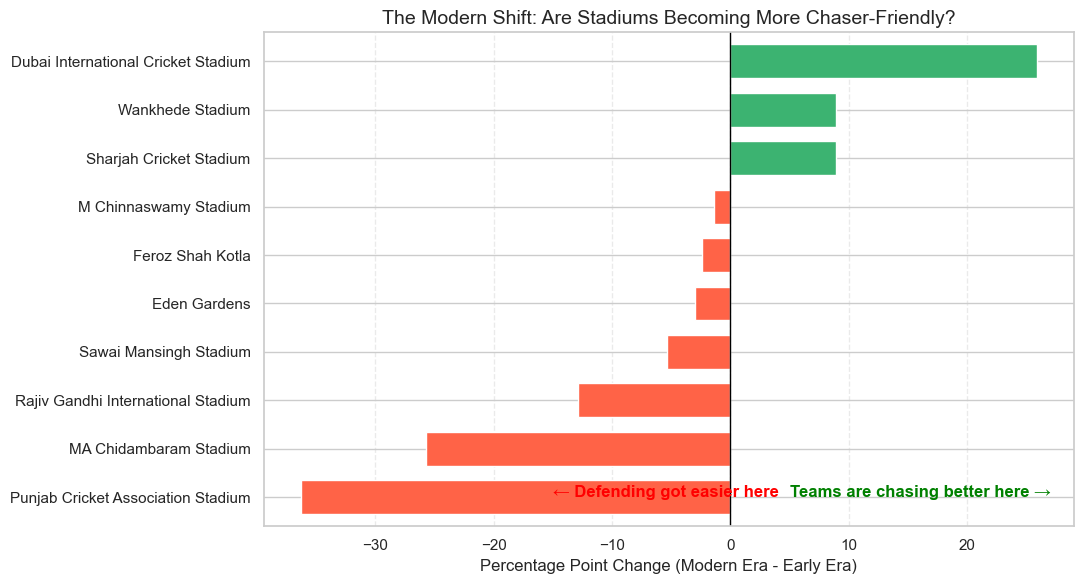

In [18]:
# I want to see the literal shift in percentage points
# Using the 'Shift' column we created in our comparison table earlier
shift_data = era_comp['Shift'].dropna().sort_values()

plt.figure(figsize=(11, 6))

# Simple horizontal bar chart
# I'm choosing colors based on whether the shift is positive (green) or negative (red)
colors = ['tomato' if x < 0 else 'mediumseagreen' for x in shift_data]

shift_data.plot(kind='barh', color=colors, width=0.7)

# Adding a vertical line at zero to show the "no change" mark
plt.axvline(0, color='black', linestyle='-', linewidth=1)

# Adding a title and labels that sound like a summary
plt.title('The Modern Shift: Are Stadiums Becoming More Chaser-Friendly?', fontsize=14)
plt.xlabel('Percentage Point Change (Modern Era - Early Era)')
plt.ylabel('') # Venue names are obvious on the Y-axis

# Adding a little note on the side for the maintainer
plt.text(5, 0, 'Teams are chasing better here →', color='green', fontweight='bold')
plt.text(-15, 0, '← Defending got easier here', color='red', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 10. Final Answers

In [19]:
# Extracting the key winners and losers for the summary
best_chase = era_comp['Modern IPL (2015+)'].idxmax()
best_defend = era_comp['Modern IPL (2015+)'].idxmin()

chase_val = era_comp.loc[best_chase, 'Modern IPL (2015+)']
defend_val = era_comp.loc[best_defend, 'Modern IPL (2015+)']

# Finding the stadiums that flipped
flipped_stadiums = era_comp[era_comp['Flip Status'] == 'YES - Flipped']

print("--- FINAL INSIGHTS (IPL Data Analysis) ---")

print(f"\n Best Venue to CHASE in the Modern Era: {best_chase}")
print(f"Chasers win {chase_val}% of the time here. If you win the toss, bowl first!")

print(f"\n Best Venue to DEFEND in the Modern Era: {best_defend}")
print(f"Chasers only win {defend_val}% of the time. This remains a defender's stronghold.")

if not flipped_stadiums.empty:
    print("\n Venues where the advantage flipped between eras:")
    for idx, row in flipped_stadiums.iterrows():
        print(f"- {idx}: Went from {row['Early IPL (pre-2015)']}% to {row['Modern IPL (2015+)']}% chasing wins.")

print("\n" + "-"*40)
print("COMPARE ALL VENUES:")
# Sorting by Modern win rate to show the trend
print(era_comp[['Early IPL (pre-2015)', 'Modern IPL (2015+)', 'Shift', 'Flip Status']])

--- FINAL INSIGHTS (IPL Data Analysis) ---

 Best Venue to CHASE in the Modern Era: Sharjah Cricket Stadium
Chasers win 70.0% of the time here. If you win the toss, bowl first!

 Best Venue to DEFEND in the Modern Era: MA Chidambaram Stadium
Chasers only win 14.3% of the time. This remains a defender's stronghold.

 Venues where the advantage flipped between eras:
- Dubai International Cricket Stadium: Went from 43.3% to 69.2% chasing wins.
- Wankhede Stadium: Went from 48.6% to 57.5% chasing wins.
- Punjab Cricket Association Stadium: Went from 61.3% to 25.0% chasing wins.

----------------------------------------
COMPARE ALL VENUES:
era                                  Early IPL (pre-2015)  Modern IPL (2015+)  \
venue_clean                                                                     
Sharjah Cricket Stadium                              61.1                70.0   
Dubai International Cricket Stadium                  43.3                69.2   
Sawai Mansingh Stadium           